# Exploratory Data Analysis

Profiles the cleaned dataset and surfaces the relationships that drive the model.

In [1]:
# --- run me first ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('working from:', ROOT.name)

working from: project


In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import config, utils, eda
sns.set(context='notebook', style='whitegrid')

In [3]:
df = utils.load_dataframe(config.DATA_DIR_PROCESSED / 'cleaned_data.csv')
summary = eda.eda_summary(df)
summary['numeric_profile'][['mean', 'std', 'min', 'max', 'skew', 'kurtosis']].round(4)

,mean,std,min,max,skew,kurtosis
mkt_excess,-0.0005,0.0103,-0.0236,0.0321,0.3847,0.1368
size,0.0002,0.0078,-0.0205,0.0208,-0.1731,-0.1464
value,-0.0008,0.0089,-0.0267,0.0229,-0.0744,0.0497
momentum,0.0004,0.0068,-0.0219,0.0491,1.2861,10.1655
asset_excess,-0.0002,0.0133,-0.0560,0.0419,0.0964,1.7033


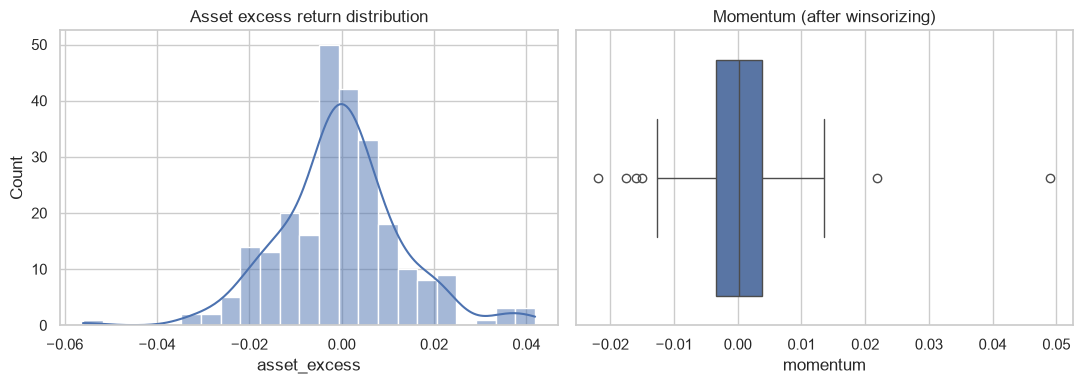

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['asset_excess'], kde=True, ax=axes[0])
axes[0].set_title('Asset excess return distribution')
sns.boxplot(x=df['momentum'], ax=axes[1])
axes[1].set_title('Momentum (after winsorizing)')
fig.tight_layout()
plt.show()

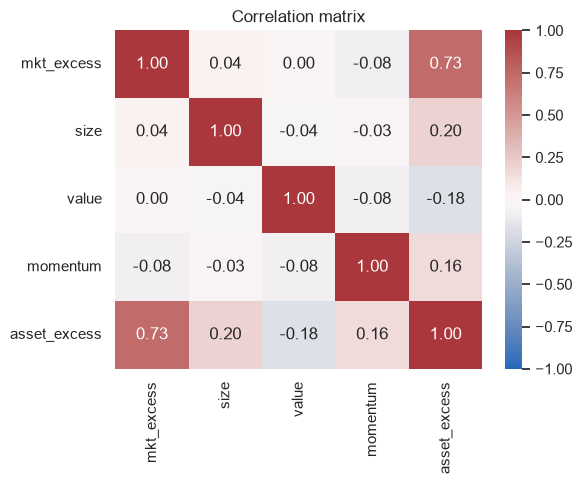

mkt_excess    0.731
size          0.201
value        -0.178
momentum      0.160
Name: asset_excess, dtype: float64

In [5]:
corr = df[['mkt_excess', 'size', 'value', 'momentum', 'asset_excess']].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation matrix')
plt.tight_layout()
plt.show()
corr['asset_excess'].drop('asset_excess').round(3)

**Takeaways.** The market factor (`mkt_excess`) is by far the strongest driver of the return (r ≈ 0.73); size, value, and momentum contribute smaller, secondary effects. `asset_excess` is roughly symmetric with heavy tails, and `momentum` is already winsorized, so its boxplot shows no extreme whiskers.